In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# These are the 14 columns in the dataset
# The last one 'num' is our target (what we want to predict)
columns = [
    'age',        # Age in years
    'sex',        # 1 = male, 0 = female
    'cp',         # Chest pain type
    'trestbps',   # Resting blood pressure
    'chol',       # Serum cholesterol
    'fbs',        # Fasting blood sugar > 120mg/dl
    'restecg',    # Resting electrocardiographic results
    'thalach',    # Maximum heart rate achieved
    'exang',      # Exercise induced angina (1=yes, 0=no)
    'oldpeak',    # ST depression induced by exercise
    'slope',      # Slope of the peak exercise ST segment
    'ca',         # Number of major vessels (0-3)
    'thal',       # Thalassemia (blood disorder)
    'num'         # Target: 0 = no disease, 1-4 = disease
]

print("Column names defined:")
print(columns)

Column names defined:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [4]:
# Load only the Cleveland file to inspect
# The '..' means "go up one folder" (from notebooks/ to heart_disease_prediction/)
cleveland_df = pd.read_csv('../data/processed.cleveland.data', 
                           header=None, 
                           names=columns, 
                           na_values='?')

print("First 5 rows of Cleveland data:")
print(cleveland_df.head())

print("\nShape of Cleveland data (rows, columns):")
print(cleveland_df.shape)  # Should show (303, 14)

First 5 rows of Cleveland data:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  

Shape of Cleveland data (rows, columns):
(303, 14)


In [5]:
# List the 4 processed files inside the 'data' folder
# NOTICE: We use '../' again to go up one folder to reach the data folder!
file_paths = [
    '../data/processed.cleveland.data',
    '../data/processed.hungarian.data',
    '../data/processed.switzerland.data',
    '../data/processed.va.data'
]

# Create an empty list to hold each dataset temporarily
list_of_dfs = []

# Loop through each file, read it, and add it to the list
for file in file_paths:
    print(f"Loading: {file} ...")
    temp_df = pd.read_csv(file, header=None, names=columns, na_values='?')
    list_of_dfs.append(temp_df)

# Concatenate (stack) all 4 dataframes into one big dataframe
df = pd.concat(list_of_dfs, ignore_index=True)

print(f"\n Success! Total rows in merged dataset: {len(df)}")

Loading: ../data/processed.cleveland.data ...
Loading: ../data/processed.hungarian.data ...
Loading: ../data/processed.switzerland.data ...
Loading: ../data/processed.va.data ...

 Success! Total rows in merged dataset: 920


In [6]:
print("--- Dataset Overview ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

print("\n--- First 3 Rows ---")
print(df.head(3))

print("\n--- Data Types (to see which are numeric vs objects) ---")
print(df.dtypes)

print("\n--- Missing Values (Count of '?' / NaN per column) ---")
print(df.isnull().sum())

--- Dataset Overview ---
Total Rows: 920, Total Columns: 14

--- First 3 Rows ---
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  

--- Data Types (to see which are numeric vs objects) ---
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object

--- Missing Values (Count of '?' / NaN per column) ---
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          

In [8]:
# ---------------------------------------------
# SMART CLEANING: Drop problematic columns first
# ---------------------------------------------

print("--- Before Cleaning ---")
print(f"Total rows: {len(df)}")
print(f"Total columns: {df.shape[1]}")   # <-- FIXED: Removed the len() here

# 1. Drop the columns that have too many missing values
columns_to_drop = ['slope', 'ca', 'thal']
df_clean = df.drop(columns=columns_to_drop)

print(f"\n Dropped columns: {columns_to_drop}")
print(f"Remaining columns: {list(df_clean.columns)}")

# 2. Now drop rows that still have missing values in the remaining columns
rows_before = len(df_clean)
df_clean = df_clean.dropna()
rows_after = len(df_clean)

print(f"\n--- After Cleaning ---")
print(f"Rows before dropping remaining NaN: {rows_before}")
print(f"Rows after dropping remaining NaN: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

# Replace the old dataframe with our new cleaned one
df = df_clean

print(f"\n Final cleaned dataset shape: {df.shape}")

--- Before Cleaning ---
Total rows: 920
Total columns: 14

 Dropped columns: ['slope', 'ca', 'thal']
Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'num']

--- After Cleaning ---
Rows before dropping remaining NaN: 920
Rows after dropping remaining NaN: 740
Rows removed: 180

 Final cleaned dataset shape: (740, 11)


In [9]:
# ---------------------------------------------
# CREATE THE BINARY TARGET VARIABLE
# ---------------------------------------------

print("--- Before creating target ---")
print(f"Current columns: {list(df.columns)}")
print(f"\nUnique values in 'num' column: {df['num'].unique()}")

# Create the new binary target
# If num > 0, target = 1 (has heart disease)
# If num == 0, target = 0 (no heart disease)
df['target'] = (df['num'] > 0).astype(int)

# Drop the old 'num' column (we don't need it anymore)
df.drop('num', axis=1, inplace=True)

print("\n--- After creating target ---")
print(f"Remaining columns: {list(df.columns)}")

print("\n Target distribution (0 = No Disease, 1 = Disease):")
print(df['target'].value_counts())

print(f"\nTotal patients WITHOUT disease (0): {(df['target'] == 0).sum()}")
print(f"Total patients WITH disease (1): {(df['target'] == 1).sum()}")

--- Before creating target ---
Current columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'num']

Unique values in 'num' column: [0 2 1 3 4]

--- After creating target ---
Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'target']

 Target distribution (0 = No Disease, 1 = Disease):
target
1    383
0    357
Name: count, dtype: int64

Total patients WITHOUT disease (0): 357
Total patients WITH disease (1): 383


In [10]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------
# SEPARATE FEATURES (X) AND TARGET (y)
# ---------------------------------------------

# X = All columns EXCEPT the target
X = df.drop('target', axis=1)

# y = Just the target column
y = df['target']

print("--- Features (X) ---")
print(f"Shape of X: {X.shape}")  # (740, 10)
print(f"Columns in X: {list(X.columns)}")

print("\n--- Target (y) ---")
print(f"Shape of y: {y.shape}")  # (740,)
print(f"Target distribution:\n{y.value_counts()}")

# ---------------------------------------------
# SPLIT INTO TRAINING AND TESTING SETS
# ---------------------------------------------

# test_size=0.2 means 20% goes to test, 80% stays for training
# random_state=42 ensures we get the same split every time we run this (for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Split Complete ---")
print(f"Training set size: {len(X_train)} rows ({(len(X_train)/len(df))*100:.1f}%)")
print(f"Testing set size:  {len(X_test)} rows ({(len(X_test)/len(df))*100:.1f}%)")

# Check that the target distribution is similar in both sets (important!)
print("\n--- Target distribution in Training set ---")
print(y_train.value_counts())

print("\n--- Target distribution in Testing set ---")
print(y_test.value_counts())

--- Features (X) ---
Shape of X: (740, 10)
Columns in X: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak']

--- Target (y) ---
Shape of y: (740,)
Target distribution:
target
1    383
0    357
Name: count, dtype: int64

--- Split Complete ---
Training set size: 592 rows (80.0%)
Testing set size:  148 rows (20.0%)

--- Target distribution in Training set ---
target
1    310
0    282
Name: count, dtype: int64

--- Target distribution in Testing set ---
target
0    75
1    73
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------
# CREATE THE SCALER AND FIT IT TO TRAINING DATA
# ---------------------------------------------

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data
# This calculates the mean and standard deviation of EACH feature in the training set
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the SAME scaler (not fit again!)
X_test_scaled = scaler.transform(X_test)

print("--- Scaling Complete ---")
print(f"Training set shape after scaling: {X_train_scaled.shape}")
print(f"Testing set shape after scaling:  {X_test_scaled.shape}")

print("\n--- Before Scaling (first 5 rows of training set) ---")
print(X_train.head(5))

print("\n--- After Scaling (first 5 rows of training set) ---")
print(X_train_scaled[:5])

print("\n--- Verification: Check if scaling worked ---")
print(f"Mean of scaled training features (should be ~0): {X_train_scaled.mean(axis=0).round(2)}")
print(f"Standard deviation of scaled training features (should be ~1): {X_train_scaled.std(axis=0).round(2)}")

--- Scaling Complete ---
Training set shape after scaling: (592, 10)
Testing set shape after scaling:  (148, 10)

--- Before Scaling (first 5 rows of training set) ---
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak
244  60.0  0.0  3.0     120.0  178.0  1.0      0.0     96.0    0.0      0.0
582  41.0  1.0  4.0     120.0  336.0  0.0      0.0    118.0    1.0      3.0
553  58.0  1.0  4.0     130.0  263.0  0.0      0.0    140.0    1.0      2.0
513  49.0  1.0  3.0     115.0  265.0  0.0      0.0    175.0    0.0      0.0
135  55.0  0.0  2.0     135.0  250.0  0.0      2.0    161.0    0.0      1.4

--- After Scaling (first 5 rows of training set) ---
[[ 0.7129274  -1.80526807 -0.25437959 -0.67626222 -0.42504071  2.40927327
  -0.76067608 -1.6191425  -0.81707138 -0.79700103]
 [-1.28832226  0.55393435  0.82902125 -0.67626222  1.25103887 -0.41506292
  -0.76067608 -0.77428225  1.22388329  1.97571949]
 [ 0.50226954  0.55393435  0.82902125 -0.15518031  0.47664767 -0.4150629

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------
# TRAIN THE LOGISTIC REGRESSION MODEL
# ---------------------------------------------

# Create the model
# max_iter=1000 ensures the algorithm has enough steps to find the best solution
model = LogisticRegression(max_iter=1000, random_state=42)

# Train (fit) the model on the TRAINING data
model.fit(X_train_scaled, y_train)

print(" Model training complete!")

# ---------------------------------------------
# MAKE PREDICTIONS ON THE TEST SET
# ---------------------------------------------

# Predict using the TEST data (the model has NEVER seen this before!)
y_pred = model.predict(X_test_scaled)

# ---------------------------------------------
# EVALUATE THE MODEL
# ---------------------------------------------

# Accuracy = percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy on Test Set: {accuracy:.4f} ({accuracy * 100:.2f}%)")

# Confusion Matrix shows:
# [True Negatives, False Positives]
# [False Negatives, True Positives]
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:")
print(cm)
print("   (Row = Actual, Column = Predicted)")
print(f"   Top-left: True Negatives  → {cm[0,0]}")
print(f"   Top-right: False Positives → {cm[0,1]}")
print(f"   Bottom-left: False Negatives → {cm[1,0]}")
print(f"   Bottom-right: True Positives  → {cm[1,1]}")

# Detailed classification report (precision, recall, f1-score)
print("\n Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

# ---------------------------------------------
# BONUS: See the model's coefficients (importance of each feature)
# ---------------------------------------------

print("\n--- Feature Importance (Coefficients) ---")
feature_names = X.columns
coefficients = model.coef_[0]

# Create a sorted list of (feature, coefficient) pairs
feature_importance = sorted(zip(feature_names, coefficients), key=lambda x: abs(x[1]), reverse=True)

print("Most important features (higher absolute value = more impact):")
for feature, coef in feature_importance:
    print(f"   {feature}: {coef:.4f}")

 Model training complete!

 Model Accuracy on Test Set: 0.8446 (84.46%)

 Confusion Matrix:
[[59 16]
 [ 7 66]]
   (Row = Actual, Column = Predicted)
   Top-left: True Negatives  → 59
   Top-right: False Positives → 16
   Bottom-left: False Negatives → 7
   Bottom-right: True Positives  → 66

 Detailed Classification Report:
                precision    recall  f1-score   support

No Disease (0)       0.89      0.79      0.84        75
   Disease (1)       0.80      0.90      0.85        73

      accuracy                           0.84       148
     macro avg       0.85      0.85      0.84       148
  weighted avg       0.85      0.84      0.84       148


--- Feature Importance (Coefficients) ---
Most important features (higher absolute value = more impact):
   cp: 0.7049
   oldpeak: 0.6320
   sex: 0.6048
   exang: 0.5158
   thalach: -0.3304
   fbs: 0.2115
   chol: -0.2007
   age: 0.1837
   trestbps: 0.1113
   restecg: 0.0901


In [17]:
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------
# TRAIN THE RANDOM FOREST MODEL
# ---------------------------------------------

# Create the model
# n_estimators=100 means 100 decision trees
# random_state=42 ensures reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train (fit) the model on the TRAINING data
rf_model.fit(X_train_scaled, y_train)

print(" Random Forest model training complete!")

# ---------------------------------------------
# MAKE PREDICTIONS ON THE TEST SET
# ---------------------------------------------

# Predict using the TEST data
y_pred_rf = rf_model.predict(X_test_scaled)

# ---------------------------------------------
# EVALUATE THE MODEL
# ---------------------------------------------

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n Random Forest Accuracy on Test Set: {accuracy_rf:.4f} ({accuracy_rf * 100:.2f}%)")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("\n Confusion Matrix (Random Forest):")
print(cm_rf)
print(f"   True Negatives: {cm_rf[0,0]}")
print(f"   False Positives: {cm_rf[0,1]}")
print(f"   False Negatives: {cm_rf[1,0]}")
print(f"   True Positives: {cm_rf[1,1]}")

# Classification Report
print("\n Detailed Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease (0)', 'Disease (1)']))

# ---------------------------------------------
# COMPARE TO LOGISTIC REGRESSION (IMPORTANT!)
# ---------------------------------------------

print("\n---  Comparison: Logistic Regression vs Random Forest ---")
print(f"Logistic Regression Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Random Forest Accuracy:      {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

if accuracy_rf > accuracy:
    print(" Random Forest performed BETTER than Logistic Regression!")
elif accuracy_rf < accuracy:
    print("  Logistic Regression performed BETTER than Random Forest.")
else:
    print(" They have the SAME accuracy!")

# ---------------------------------------------
# FEATURE IMPORTANCE (Random Forest is great at this!)
# ---------------------------------------------

print("\n---  Random Forest Feature Importance ---")
feature_names = X.columns
importances = rf_model.feature_importances_

# Create a sorted list of (feature, importance) pairs
feature_importance_rf = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("Most important features according to Random Forest:")
for feature, imp in feature_importance_rf:
    print(f"   {feature}: {imp:.4f}")

 Random Forest model training complete!

 Random Forest Accuracy on Test Set: 0.8446 (84.46%)

 Confusion Matrix (Random Forest):
[[61 14]
 [ 9 64]]
   True Negatives: 61
   False Positives: 14
   False Negatives: 9
   True Positives: 64

 Detailed Classification Report (Random Forest):
                precision    recall  f1-score   support

No Disease (0)       0.87      0.81      0.84        75
   Disease (1)       0.82      0.88      0.85        73

      accuracy                           0.84       148
     macro avg       0.85      0.85      0.84       148
  weighted avg       0.85      0.84      0.84       148


---  Comparison: Logistic Regression vs Random Forest ---
Logistic Regression Accuracy: 0.8446 (84.46%)
Random Forest Accuracy:      0.8446 (84.46%)
 They have the SAME accuracy!

---  Random Forest Feature Importance ---
Most important features according to Random Forest:
   thalach: 0.1567
   cp: 0.1564
   chol: 0.1406
   oldpeak: 0.1165
   age: 0.1144
   exang: 0.103

In [18]:
# ---------------------------------------------
# STEP 1: INSTALL XGBOOST (if not already installed)
# ---------------------------------------------
# The '%' tells Jupyter to run this as a terminal command
%pip install xgboost -q

# Import the library
import xgboost as xgb

# ---------------------------------------------
# STEP 2: TRAIN THE XGBOOST MODEL
# ---------------------------------------------

# 'use_label_encoder=False' and 'eval_metric='logloss'' stop annoying warning messages
# 'learning_rate=0.1' controls how fast the model learns (smaller = more careful, but slower)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,          # Number of trees
    learning_rate=0.1,         # Step size shrinkage
    max_depth=6,               # Maximum tree depth
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
print(" Training XGBoost...")
xgb_model.fit(X_train_scaled, y_train)
print(" XGBoost model training complete!")

# ---------------------------------------------
# STEP 3: EVALUATE ON THE TEST SET
# ---------------------------------------------

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\n XGBoost Accuracy on Test Set: {accuracy_xgb:.4f} ({accuracy_xgb * 100:.2f}%)")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\n Confusion Matrix (XGBoost):")
print(cm_xgb)
print(f"   True Negatives: {cm_xgb[0,0]}")
print(f"   False Positives: {cm_xgb[0,1]}")
print(f"   False Negatives: {cm_xgb[1,0]}")
print(f"   True Positives: {cm_xgb[1,1]}")

# Classification Report
print("\n Detailed Classification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=['No Disease (0)', 'Disease (1)']))

# ---------------------------------------------
# STEP 4: THREE-WAY MODEL COMPARISON! 
# ---------------------------------------------

print("\n" + "="*50)
print(" THREE-WAY MODEL COMPARISON ")
print("="*50)
print(f"1. Logistic Regression: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"2. Random Forest:       {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"3. XGBoost:             {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")

# Find the best
accuracies = {
    "Logistic Regression": accuracy,
    "Random Forest": accuracy_rf,
    "XGBoost": accuracy_xgb
}
best_model = max(accuracies, key=accuracies.get)
print(f"\n BEST MODEL: {best_model} with {accuracies[best_model]*100:.2f}% accuracy!")

# ---------------------------------------------
# STEP 5: XGBOOST FEATURE IMPORTANCE
# ---------------------------------------------

print("\n---  XGBoost Feature Importance ---")
feature_names = X.columns
importances_xgb = xgb_model.feature_importances_

# Create a sorted list
feature_importance_xgb = sorted(zip(feature_names, importances_xgb), key=lambda x: x[1], reverse=True)

print("Most important features according to XGBoost:")
for feature, imp in feature_importance_xgb:
    print(f"   {feature}: {imp:.4f}")


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
 Training XGBoost...
 XGBoost model training complete!

 XGBoost Accuracy on Test Set: 0.8378 (83.78%)

 Confusion Matrix (XGBoost):
[[61 14]
 [10 63]]
   True Negatives: 61
   False Positives: 14
   False Negatives: 10
   True Positives: 63

 Detailed Classification Report (XGBoost):
                precision    recall  f1-score   support

No Disease (0)       0.86      0.81      0.84        75
   Disease (1)       0.82      0.86      0.84        73

      accuracy                           0.84       148
     macro avg       0.84      0.84      0.84       148
  weighted avg       0.84      0.84      0.84       148


 THREE-WAY MODEL COMPARISON 
1. Logistic Regression: 0.8446 (84.46%)
2. Random Forest:       0.8446 (84.46%)
3. XGBoost:             0.8378 (83.78%)

 BEST MODEL: Logistic Regression with 84.46% accuracy!

---  XGBoost Feature Importance ---
Most important features according to XGBoost:
   cp: 0.3385
   exa

C:\Users\hp3\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:46:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# This makes graphs appear directly in your notebook
%matplotlib inline

# Set a nice visual style
sns.set_style("whitegrid")

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


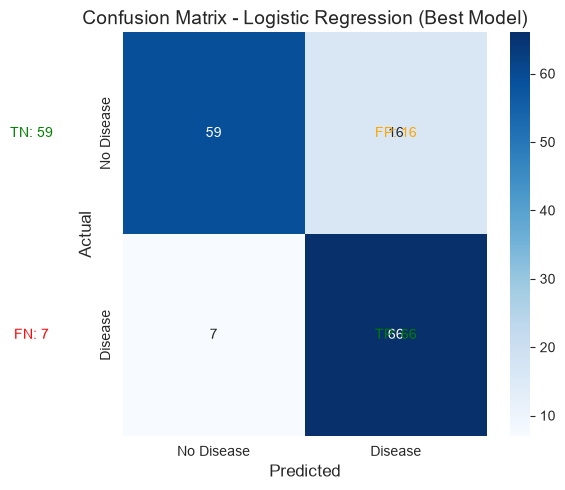

In [20]:
# ---------------------------------------------
# CONFUSION MATRIX HEATMAP
# ---------------------------------------------

# Use the Logistic Regression predictions (our best model)
cm = confusion_matrix(y_test, y_pred)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])

plt.title('Confusion Matrix - Logistic Regression (Best Model)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)

# Add text annotations explaining the quadrants
plt.text(-0.5, 0.5, f"TN: {cm[0,0]}", ha='center', va='center', fontsize=10, color='green')
plt.text(1.5, 0.5, f"FP: {cm[0,1]}", ha='center', va='center', fontsize=10, color='orange')
plt.text(-0.5, 1.5, f"FN: {cm[1,0]}", ha='center', va='center', fontsize=10, color='red')
plt.text(1.5, 1.5, f"TP: {cm[1,1]}", ha='center', va='center', fontsize=10, color='green')

plt.tight_layout()
plt.show()

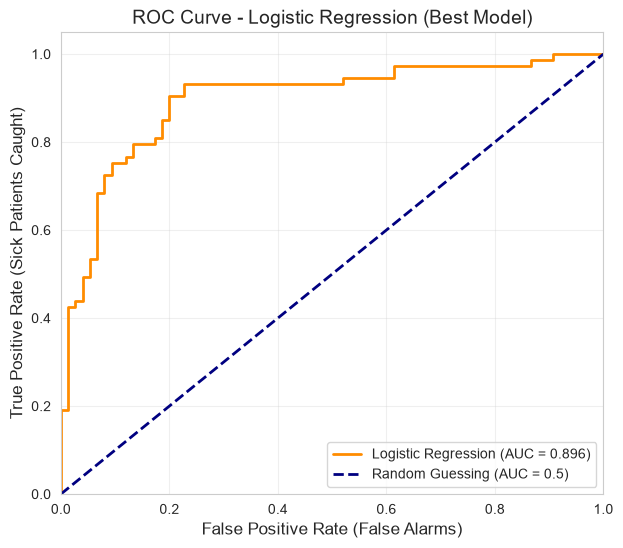

 AUC Score: 0.8955 (89.55%)
Interpretation: An AUC of 0.90+ means the model is excellent at distinguishing between sick and healthy patients.


In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

# ---------------------------------------------
# ROC CURVE - LOGISTIC REGRESSION
# ---------------------------------------------

# Get predicted probabilities (not just class labels)
# This gives us the model's "confidence" for each prediction
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

# Create the plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Sick Patients Caught)', fontsize=12)
plt.title('ROC Curve - Logistic Regression (Best Model)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f" AUC Score: {auc_score:.4f} ({auc_score*100:.2f}%)")
print("Interpretation: An AUC of 0.90+ means the model is excellent at distinguishing between sick and healthy patients.")

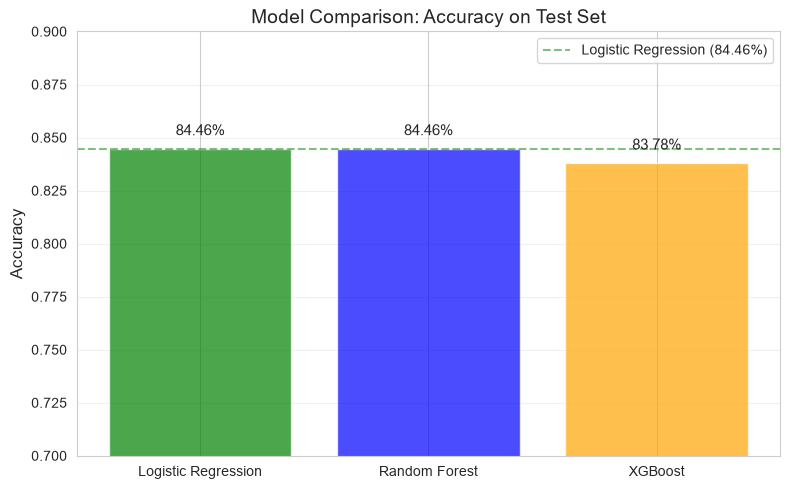

In [23]:
# ---------------------------------------------
# MODEL COMPARISON BAR CHART
# ---------------------------------------------

# Data
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [accuracy, accuracy_rf, accuracy_xgb]
colors = ['green', 'blue', 'orange']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, alpha=0.7)

# Add value labels on top of bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc*100:.2f}%', ha='center', va='bottom', fontsize=11)

plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison: Accuracy on Test Set', fontsize=14)
plt.ylim(0.7, 0.9)
plt.grid(axis='y', alpha=0.3)

# Add a horizontal line at Logistic Regression's accuracy
plt.axhline(y=accuracy, color='green', linestyle='--', alpha=0.5, label=f'Logistic Regression ({accuracy*100:.2f}%)')

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
import joblib
import os

# 1. Create a 'models' folder in your main project directory
# (The '..' goes up from 'notebooks/' to 'heart_disease_prediction/')
os.makedirs('../models', exist_ok=True)

# 2. Save your best model (Logistic Regression)
joblib.dump(model, '../models/heart_model.pkl')

# 3. Save the scaler (so we can scale new inputs)
joblib.dump(scaler, '../models/scaler.pkl')

print(" Model saved to: models/heart_model.pkl")
print(" Scaler saved to: models/scaler.pkl")
print("\nYour project folder now contains:")
print("    heart_disease_prediction/")
print("   └──  models/")
print("       ├── heart_model.pkl")
print("       └── scaler.pkl")

 Model saved to: models/heart_model.pkl
 Scaler saved to: models/scaler.pkl

Your project folder now contains:
    heart_disease_prediction/
   └──  models/
       ├── heart_model.pkl
       └── scaler.pkl
